In [16]:
import pandas as pd

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
trades = pd.read_csv("historical_data.csv")

In [20]:
sentiment = pd.read_csv("/feargreed_index.csv")

In [21]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [23]:
trades.shape

(18608, 16)

In [24]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
sentiment.shape

(2644, 4)

In [26]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

In [27]:
trades["date"] = trades["Timestamp IST"].dt.date

In [28]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [29]:
merged = trades.merge(
    sentiment[["date", "classification", "value"]],
    on="date",
    how="left"
)


In [30]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [31]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")


In [32]:
trades["Timestamp IST"].head()

,Timestamp IST
0,2024-12-02 22:50:00
1,2024-12-02 22:50:00
2,2024-12-02 22:50:00
3,2024-12-02 22:50:00
4,2024-12-02 22:50:00


In [33]:
merged.groupby("classification")["Closed PnL"].mean().sort_values()


,Closed PnL
classification,
Extreme Greed,65.938570
Greed,136.216495
Neutral,178.839679
Fear,194.770442
Extreme Fear,338.916162


In [34]:
merged["is_profitable"] = merged["Closed PnL"] > 0
merged.groupby("classification")["is_profitable"].mean()


,is_profitable
classification,
Extreme Fear,0.322624
Extreme Greed,0.115000
Fear,0.415617
Greed,0.350380
Neutral,0.542618


In [35]:
merged.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Fear,2.531704e+05
Extreme Greed,1.055017e+05
Fear,1.638799e+06
Greed,6.445765e+05
Neutral,5.558337e+05


In [36]:
merged.groupby("classification")["Size USD"].mean()


,Size USD
classification,
Extreme Fear,7681.766118
Extreme Greed,8437.322281
Fear,30507.735890
Greed,28036.998658
Neutral,25814.644156


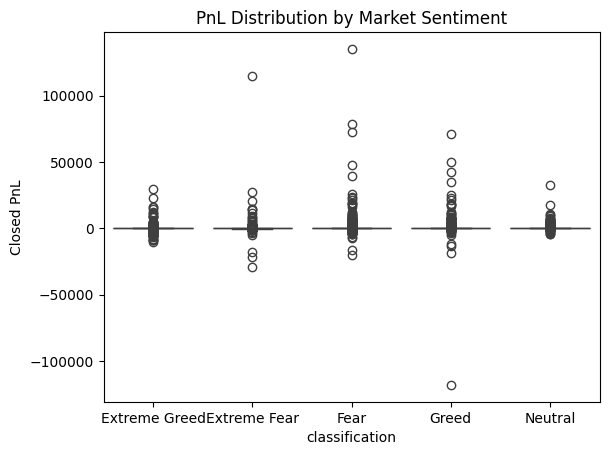

In [37]:
sns.boxplot(x="classification", y="Closed PnL", data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()


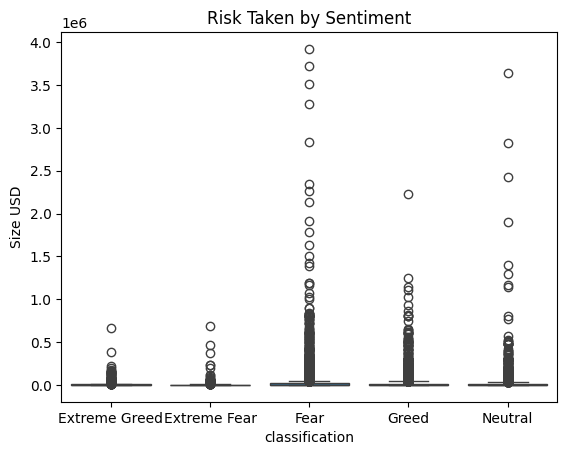

In [38]:
sns.boxplot(x="classification", y="Size USD", data=merged)
plt.title("Risk Taken by Sentiment")
plt.show()


In [39]:
fear = merged[merged["classification"].str.contains("Fear", na=False)]


In [40]:
greed = merged[merged["classification"].str.contains("Greed", na=False)]

In [41]:
fear[["Closed PnL", "Size USD"]].describe()

,Closed PnL,Size USD
count,9161.000000,9.161000e+03
mean,206.524274,2.864648e+04
std,2542.258607,1.252130e+05
min,-29370.119800,1.400000e-01
25%,0.000000,5.533400e+02
50%,0.000000,1.709970e+03
75%,15.987000,1.383985e+04
max,135329.090100,3.921431e+06


In [42]:
greed[["Closed PnL", "Size USD"]].describe()

,Closed PnL,Size USD
count,6332.000000,6.332000e+03
mean,118.458333,2.308446e+04
std,2318.449473,7.592365e+04
min,-117990.104100,3.000000e-02
25%,0.000000,5.223275e+02
50%,0.000000,2.149245e+03
75%,0.520855,1.201742e+04
max,71535.716740,2.227115e+06


In [43]:
merged[["value", "Closed PnL", "Size USD"]].corr()


,value,Closed PnL,Size USD
value,1.000000,-0.022688,-0.025913
Closed PnL,-0.022688,1.000000,0.130197
Size USD,-0.025913,0.130197,1.000000


In [44]:
merged[["value", "Closed PnL", "Size USD"]].corr()


,value,Closed PnL,Size USD
value,1.000000,-0.022688,-0.025913
Closed PnL,-0.022688,1.000000,0.130197
Size USD,-0.025913,0.130197,1.000000


In [45]:
merged.groupby("classification")["Closed PnL"].mean()
merged["is_profitable"] = merged["Closed PnL"] > 0
merged.groupby("classification")["is_profitable"].mean()

,is_profitable
classification,
Extreme Fear,0.322624
Extreme Greed,0.115000
Fear,0.415617
Greed,0.350380
Neutral,0.542618


In [46]:
merged.groupby("classification")["Size USD"].mean()


,Size USD
classification,
Extreme Fear,7681.766118
Extreme Greed,8437.322281
Fear,30507.735890
Greed,28036.998658
Neutral,25814.644156


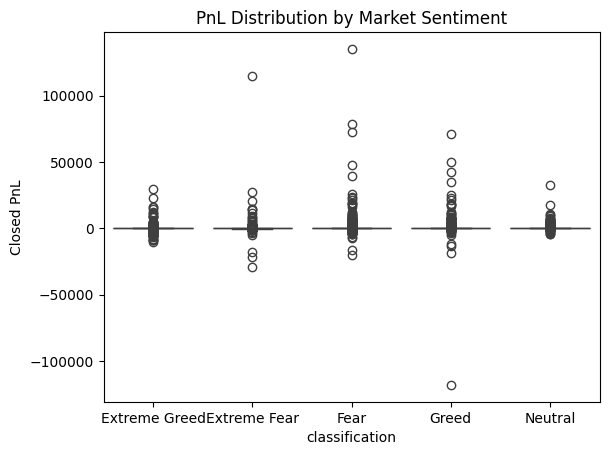

In [47]:
sns.boxplot(x="classification", y="Closed PnL", data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()